#  Customer Payment Probability Prediction
### Loan Recovery Analysis — Feb 2023 to Jul 2023

---

**Objective:** Build a classifier that predicts whether a customer in loan recovery will make a payment in a given month.

**Dataset:** 6-month window (Feb '23 – Jul '23) covering ~348,000 account-month records across 27 fields — including outstanding principal, days-past-due, EMI amounts, CIBIL scores, and borrower demographics.



---

## 1. Setup — Importing Libraries

We start by loading all the libraries we'll need throughout this notebook. I

- **pandas / numpy** — for data wrangling and numerical operations
- **matplotlib / seaborn** — for all our charts and visualisations
- **sklearn** — for building and evaluating our machine learning models

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve

import warnings
warnings.filterwarnings('ignore')

# Set a consistent visual theme for all charts
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print("All libraries loaded successfully.")

All libraries loaded successfully.


---
## 2. Load & Inspect the Data

Let's load the CSV and take a quick first look. We want to confirm:
- How many rows and columns we have
- Which months are covered
- What the first few records look like



In [3]:
df = pd.read_csv('Data_6Months.csv')

print(f"Dataset shape: {df.shape[0]:,} rows  x  {df.shape[1]} columns")
print(f"\nMonths covered (month_end_date): {sorted(df['month_end_date'].unique())}")
print("\nFirst 3 rows:")
df.head(3)

Dataset shape: 348,151 rows  x  27 columns

Months covered (month_end_date): ['2023-02-28', '2023-03-31', '2023-04-30', '2023-05-31', '2023-06-30', '2023-07-31']

First 3 rows:


,Account_number,Principal_outstanding,dpd_days,dpd_bucket,prod_name,disbursal_date,disb_amt,tenor,roi,emi,...,final_veri_monthly_income,writeoff_date,gwo_amt,dpd_days_wo,source,loan_program_type,final_dbr,total_outstanding,Pmt_amount,month_end_date
0,1.151000e+11,0.0,4380.0,NCL,PL_SELF,27/01/09 00:00,105000.0,24.0,32.380001,6035.0,...,NaN,01-Jun-11,5884.0,146.0,NaN,STANDARD,NaN,NaN,0.0,2023-02-28
1,1.152000e+11,0.0,0.0,NCL,PL_SELF,12/09/08 00:00,200000.0,20.0,22.969999,12065.0,...,NaN,01-Sep-10,11844.0,149.0,NaN,STANDARD,NaN,NaN,0.0,2023-02-28
2,1.152000e+11,0.0,4046.0,NCL,PL_SELF,28/12/08 00:00,650000.0,36.0,22.219999,24993.0,...,NaN,01-May-12,24464.0,148.0,NaN,STANDARD,NaN,NaN,0.0,2023-02-28


---
## 3. Data Quality Check

Before touching anything, we need to understand what we're working with. This section produces our **one-page data-quality summary** as required by the assignment.

We check for:
- Columns with missing values and how severe they are
- Hidden nulls (like `cibil_score = 0`, which means 'no data', not an actual score of zero)
- The distribution of our target variable `Pmt_amount` — and whether we have a class imbalance problem

In [4]:
# Build a clean summary table of missing values
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %':     (df.isnull().sum() / len(df) * 100).round(2),
    'Dtype':         df.dtypes
}).sort_values('Missing %', ascending=False)

print("=== Missing Value Summary ===")
print(missing[missing['Missing Count'] > 0].to_string())

# CIBIL score of 0 is not a real score — it means 'no credit history'
# We treat these as hidden nulls
hidden_nulls = (df['cibil_score'] == 0).sum()
print(f"\nCIBIL score rows where value is exactly 0 (hidden nulls): {hidden_nulls:,}")

# Target variable: Pmt_amount
print("\n=== Target Variable: Pmt_amount ===")
print(df['Pmt_amount'].describe().round(2))

payers      = (df['Pmt_amount'].fillna(0) > 0).sum()
total_valid = df['Pmt_amount'].notna().sum()
print(f"\nAccounts that made any payment: {payers:,} out of {total_valid:,} ({payers/total_valid*100:.1f}%)")
print(f"Negative Pmt_amount rows (likely reversals or corrections): {(df['Pmt_amount'] < 0).sum():,}")

=== Missing Value Summary ===
                           Missing Count  Missing %    Dtype
total_work_exp_months             329406      94.62  float64
industry_type                     329415      94.62   object
emp_type                          329406      94.62   object
total_outstanding                 290960      83.57   object
final_veri_monthly_income         108460      31.15  float64
final_dbr                         105000      30.16  float64
pincode                            87292      25.07  float64
residence_state                    25430       7.30   object
residence_city                     25431       7.30   object
cibil_score                        10928       3.14  float64
source                              8015       2.30   object
loan_program_type                   1559       0.45   object
Pmt_amount                          1154       0.33  float64
dpd_days_wo                          159       0.05  float64
roi                                  149       0.04  fl

### Data Quality Summary — Visual

The chart on the left shows which columns have missing data and how bad it is:
- **Red bars** (>80% missing) → these columns will be dropped; too little data to be useful
- **Orange bars** (30–80% missing) → handle with imputation
- **Blue bars** (<30% missing) → straightforward to fill

The pie chart on the right confirms our class imbalance — only about **9% of account-months** result in a payment. This matters a lot for how we train our model.

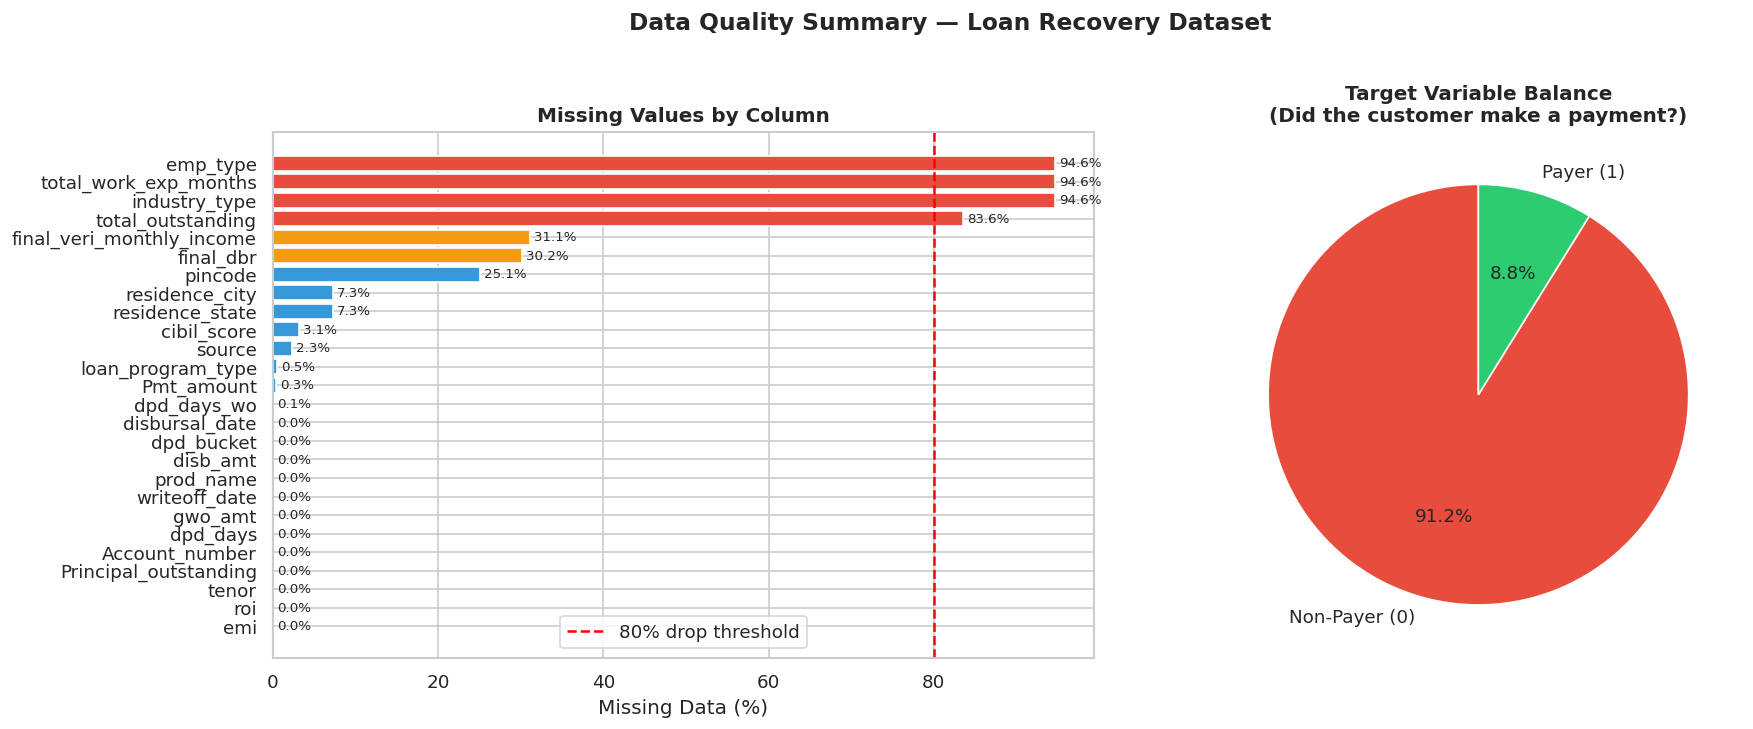

Saved: data_quality_summary.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Data Quality Summary — Loan Recovery Dataset', fontsize=14, fontweight='bold', y=1.01)

# Left chart: Missing % per column
missing_plot = missing[missing['Missing %'] > 0]['Missing %'].sort_values()
colors       = ['#e74c3c' if v > 80 else '#f39c12' if v > 30 else '#3498db' for v in missing_plot.values]
bars         = axes[0].barh(missing_plot.index, missing_plot.values, color=colors)

axes[0].axvline(x=80, color='red', linestyle='--', linewidth=1.5, label='80% drop threshold')
axes[0].set_xlabel('Missing Data (%)')
axes[0].set_title('Missing Values by Column', fontweight='bold')
axes[0].legend()

for bar, val in zip(bars, missing_plot.values):
    axes[0].text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}%', va='center', fontsize=8)

# Right chart: Target class balance
labels     = ['Non-Payer (0)', 'Payer (1)']
sizes      = [total_valid - payers, payers]
pie_colors = ['#e74c3c', '#2ecc71']

wedges, texts, autotexts = axes[1].pie(
    sizes, labels=labels, colors=pie_colors,
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 11}
)
axes[1].set_title('Target Variable Balance\n(Did the customer make a payment?)', fontweight='bold')

plt.tight_layout()
plt.savefig('data_quality_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data_quality_summary.png")

---
## 4. Data Cleaning

Based on the quality check, here's our cleaning plan:

| Issue | Action |
|---|---|
| Columns >80% missing | Drop them entirely |
| `cibil_score` = 0 | Treat as null; create a `cibil_missing_flag` column |
| Other numeric nulls | Fill with column median |
| Categorical nulls | Replace with 'Unknown' |
| Negative `Pmt_amount` | Clip to 0 (treat as reversals) |
| Date columns | Parse to proper datetime format |

We also engineer two new features:
- **`cibil_missing_flag`** — tells the model whether a borrower has no credit history (very different from having a low score)
- **`loan_age_days`** — how old the loan is; models can't learn from raw dates, but they can learn from a number

In [6]:
df_clean = df.copy()

# --- Step 1: Drop columns that are >80% empty ---
cols_to_drop = ['industry_type', 'emp_type', 'total_work_exp_months', 'total_outstanding']
df_clean = df_clean.drop(columns=cols_to_drop)
print(f"Dropped columns (>80% missing): {cols_to_drop}")

# --- Step 2: Handle the target variable ---
# Remove rows where Pmt_amount is completely unknown
# Clip negative values to 0 (reversals / data errors)
df_clean = df_clean.dropna(subset=['Pmt_amount'])
df_clean['Pmt_amount'] = df_clean['Pmt_amount'].clip(lower=0)
df_clean['is_payer']   = (df_clean['Pmt_amount'] > 0).astype(int)

# --- Step 3: CIBIL score — flag hidden nulls before filling ---
# A score of 0 or -1 means 'no credit data available', not an actual score
# We create a flag first so the model knows WHY the score is missing
df_clean['cibil_score']        = df_clean['cibil_score'].replace([0, -1], np.nan)
df_clean['cibil_missing_flag'] = df_clean['cibil_score'].isna().astype(int)
df_clean['cibil_score']        = df_clean['cibil_score'].fillna(df_clean['cibil_score'].median())

# --- Step 4: Fill remaining numeric columns with median ---
numeric_fill = ['final_veri_monthly_income', 'final_dbr', 'disb_amt',
                'roi', 'emi', 'gwo_amt', 'dpd_days_wo', 'pincode']
for col in numeric_fill:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# --- Step 5: Clean categorical columns ---
cat_cols = ['residence_state', 'residence_city', 'source', 'loan_program_type', 'dpd_bucket', 'prod_name']
for col in cat_cols:
    df_clean[col] = df_clean[col].astype(str).replace({'nan': 'Unknown', '<NA>': 'Unknown'})

# --- Step 6: Parse dates ---
df_clean['month_end_date'] = pd.to_datetime(df_clean['month_end_date'], errors='coerce')
df_clean['disbursal_date'] = pd.to_datetime(df_clean['disbursal_date'], dayfirst=True, errors='coerce')

# --- Step 7: Feature — Loan Age in Days ---
# Static dates are meaningless to a model. Converting to a number
# (days since disbursal) gives it something it can actually learn from.
df_clean['loan_age_days'] = (df_clean['month_end_date'] - df_clean['disbursal_date']).dt.days
df_clean['loan_age_days'] = df_clean['loan_age_days'].fillna(df_clean['loan_age_days'].median())

print(f"\nClean dataset: {df_clean.shape[0]:,} rows, {df_clean.shape[1]} columns")
print("\nTarget split:")
print(df_clean['is_payer'].value_counts(normalize=True).mul(100).round(1).rename({1: 'Payer %', 0: 'Non-Payer %'}))

Dropped columns (>80% missing): ['industry_type', 'emp_type', 'total_work_exp_months', 'total_outstanding']

Clean dataset: 346,997 rows, 26 columns

Target split:
is_payer
Non-Payer %    91.2
Payer %         8.8
Name: proportion, dtype: float64


### Outlier Treatment — 99th Percentile Capping

A few financial columns have extreme outliers that can distort both our charts and our model. For example, a single loan with a principal of ₹10 crore would make all the other bars look flat in a histogram.

We cap values at the **99th percentile** — this preserves the natural distribution while removing the extreme tail. We're not deleting these rows, just limiting the extreme values.

In [7]:
cols_to_cap = ['Principal_outstanding', 'disb_amt', 'emi', 'final_veri_monthly_income', 'gwo_amt']

print("Outlier capping at 99th percentile:")
for col in cols_to_cap:
    cap    = df_clean[col].quantile(0.99)
    n_rows = (df_clean[col] > cap).sum()
    df_clean[col] = df_clean[col].clip(upper=cap)
    print(f"  {col}: capped {n_rows:,} rows at {cap:,.0f}")

# Quick sanity check on monthly payer rates
monthly_rate = (
    df_clean
    .groupby(df_clean['month_end_date'].dt.strftime('%Y-%m'))['is_payer']
    .mean()
    .mul(100)
    .round(2)
)
print("\nMonthly payment rate (% of accounts that paid in each month):")
print(monthly_rate.to_string())

Outlier capping at 99th percentile:
  Principal_outstanding: capped 3,466 rows at 952,567
  disb_amt: capped 3,465 rows at 1,042,564
  emi: capped 3,460 rows at 34,515
  final_veri_monthly_income: capped 3,468 rows at 66,449
  gwo_amt: capped 3,465 rows at 971,640

Monthly payment rate (% of accounts that paid in each month):
month_end_date
2023-02    10.53
2023-03     9.30
2023-04     7.49
2023-05     8.70
2023-06     8.52
2023-07     8.54


---
## 5. Exploratory Data Analysis (EDA)

Now for the interesting part — let's understand what's actually in this data.

### 5.1 Account Distribution

We look at how accounts are spread across three dimensions:
- **DPD Bucket** — how overdue are the loans?
- **Product Name** — which loan products dominate the portfolio?
- **State** — where are the borrowers located?

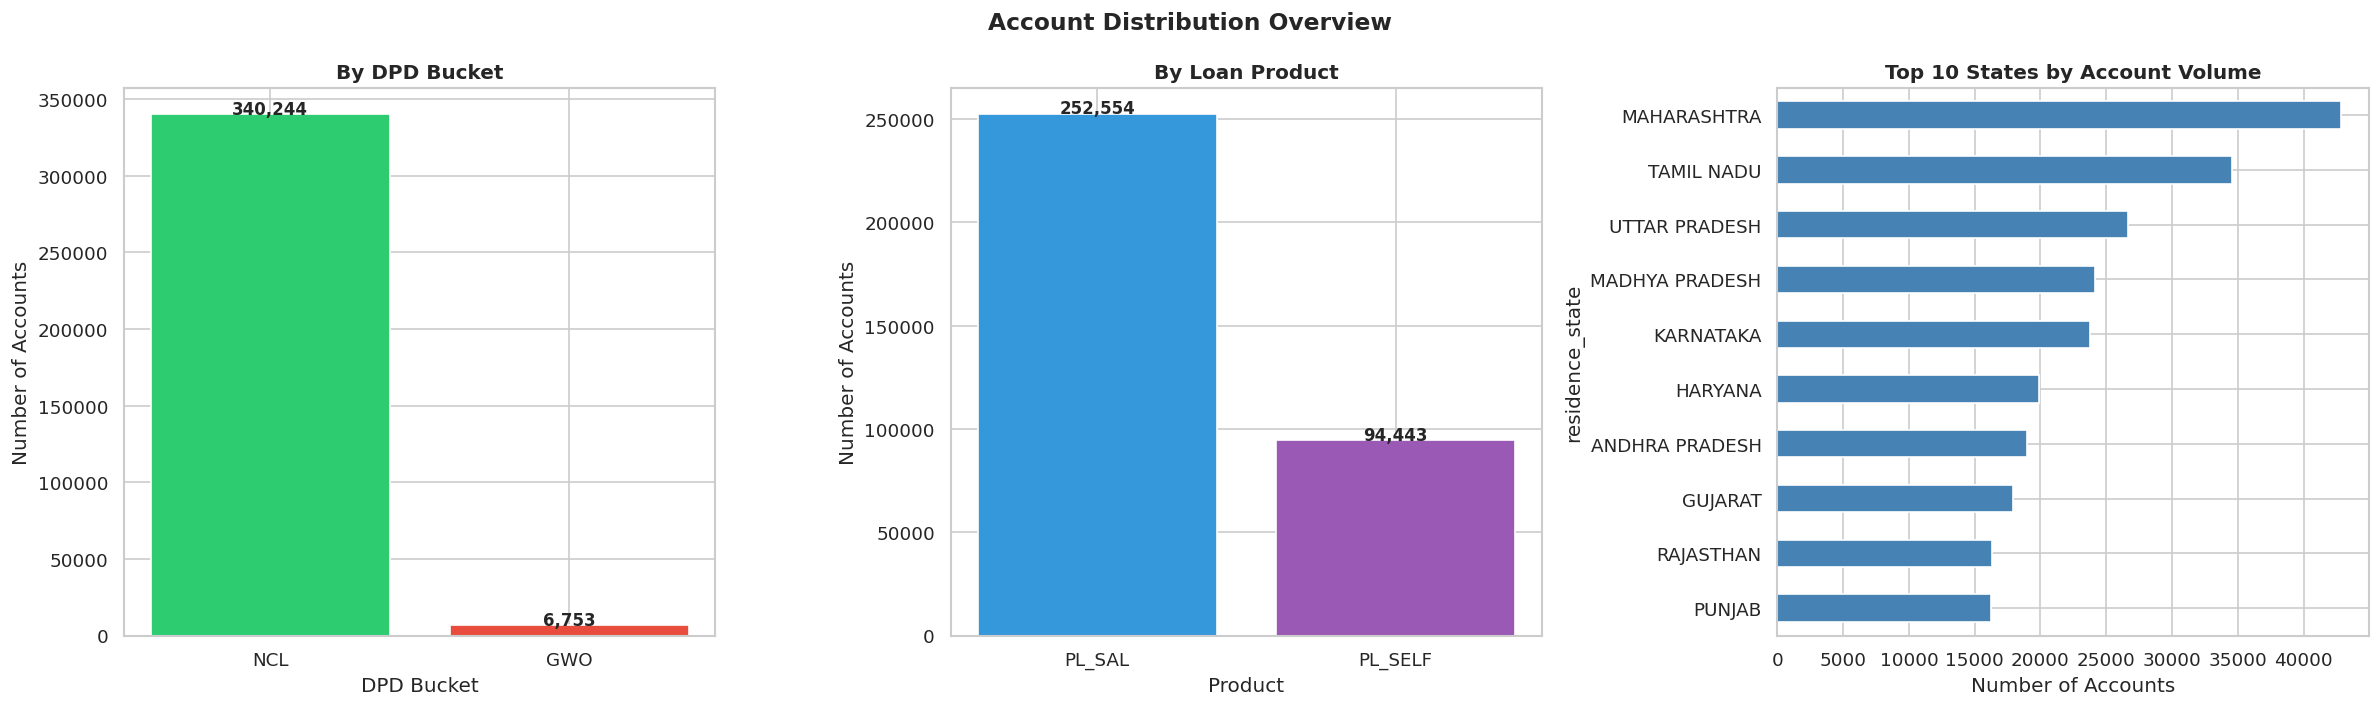

Saved: eda_distribution.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Account Distribution Overview', fontsize=14, fontweight='bold')

# Chart 1: Distribution by DPD Bucket
dpd_counts = df_clean['dpd_bucket'].value_counts()
bars1      = axes[0].bar(dpd_counts.index, dpd_counts.values,
                         color=['#2ecc71', '#e74c3c', '#95a5a6'])
axes[0].set_title('By DPD Bucket', fontweight='bold')
axes[0].set_ylabel('Number of Accounts')
axes[0].set_xlabel('DPD Bucket')
for bar, val in zip(bars1, dpd_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
                 f'{val:,}', ha='center', fontsize=10, fontweight='bold')

# Chart 2: Distribution by Loan Product
prod_counts = df_clean['prod_name'].value_counts()
bars2       = axes[1].bar(prod_counts.index, prod_counts.values,
                          color=['#3498db', '#9b59b6', '#95a5a6'])
axes[1].set_title('By Loan Product', fontweight='bold')
axes[1].set_ylabel('Number of Accounts')
axes[1].set_xlabel('Product')
for bar, val in zip(bars2, prod_counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
                 f'{val:,}', ha='center', fontsize=10, fontweight='bold')

# Chart 3: Top 10 States by Account Volume
top_states = (
    df_clean[df_clean['residence_state'] != 'Unknown']['residence_state']
    .value_counts()
    .nlargest(10)
    .sort_values()
)
top_states.plot(kind='barh', ax=axes[2], color='steelblue')
axes[2].set_title('Top 10 States by Account Volume', fontweight='bold')
axes[2].set_xlabel('Number of Accounts')

plt.tight_layout()
plt.savefig('eda_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eda_distribution.png")

### 5.2 Payment Trends — Month over Month

We now look at how payments evolved across the 6-month window:
- **Total EMI collected** per month (in INR)
- **Number of unique payers** per month
- **Collection amount vs payer rate** on a dual-axis chart
- **Active vs Delinquent pool** as a stacked bar

The stacked bar is particularly useful — it shows us not just payment rates, but the size of the problem at each point in time.

In [9]:
# Aggregate by month
monthly = (
    df_clean
    .groupby(df_clean['month_end_date'].dt.strftime('%Y-%m'))
    .agg(
        total_collected  = ('Pmt_amount',    'sum'),
        unique_payers    = ('is_payer',       'sum'),
        total_accounts   = ('Account_number', 'count')
    )
    .reset_index()
)
monthly['delinquent_accounts'] = monthly['total_accounts'] - monthly['unique_payers']
monthly['payer_rate_pct']      = (monthly['unique_payers'] / monthly['total_accounts'] * 100).round(2)

print("=== Monthly Payment Summary ===")
print(monthly.to_string(index=False))

=== Monthly Payment Summary ===
month_end_date  total_collected  unique_payers  total_accounts  delinquent_accounts  payer_rate_pct
       2023-02     148990208.26           5993           56894                50901           10.53
       2023-03     129282940.88           5275           56747                51472            9.30
       2023-04      91315822.30           4284           57170                52886            7.49
       2023-05     114706536.40           5088           58509                53421            8.70
       2023-06     126657792.41           5029           58998                53969            8.52
       2023-07     117245157.83           5014           58679                53665            8.54


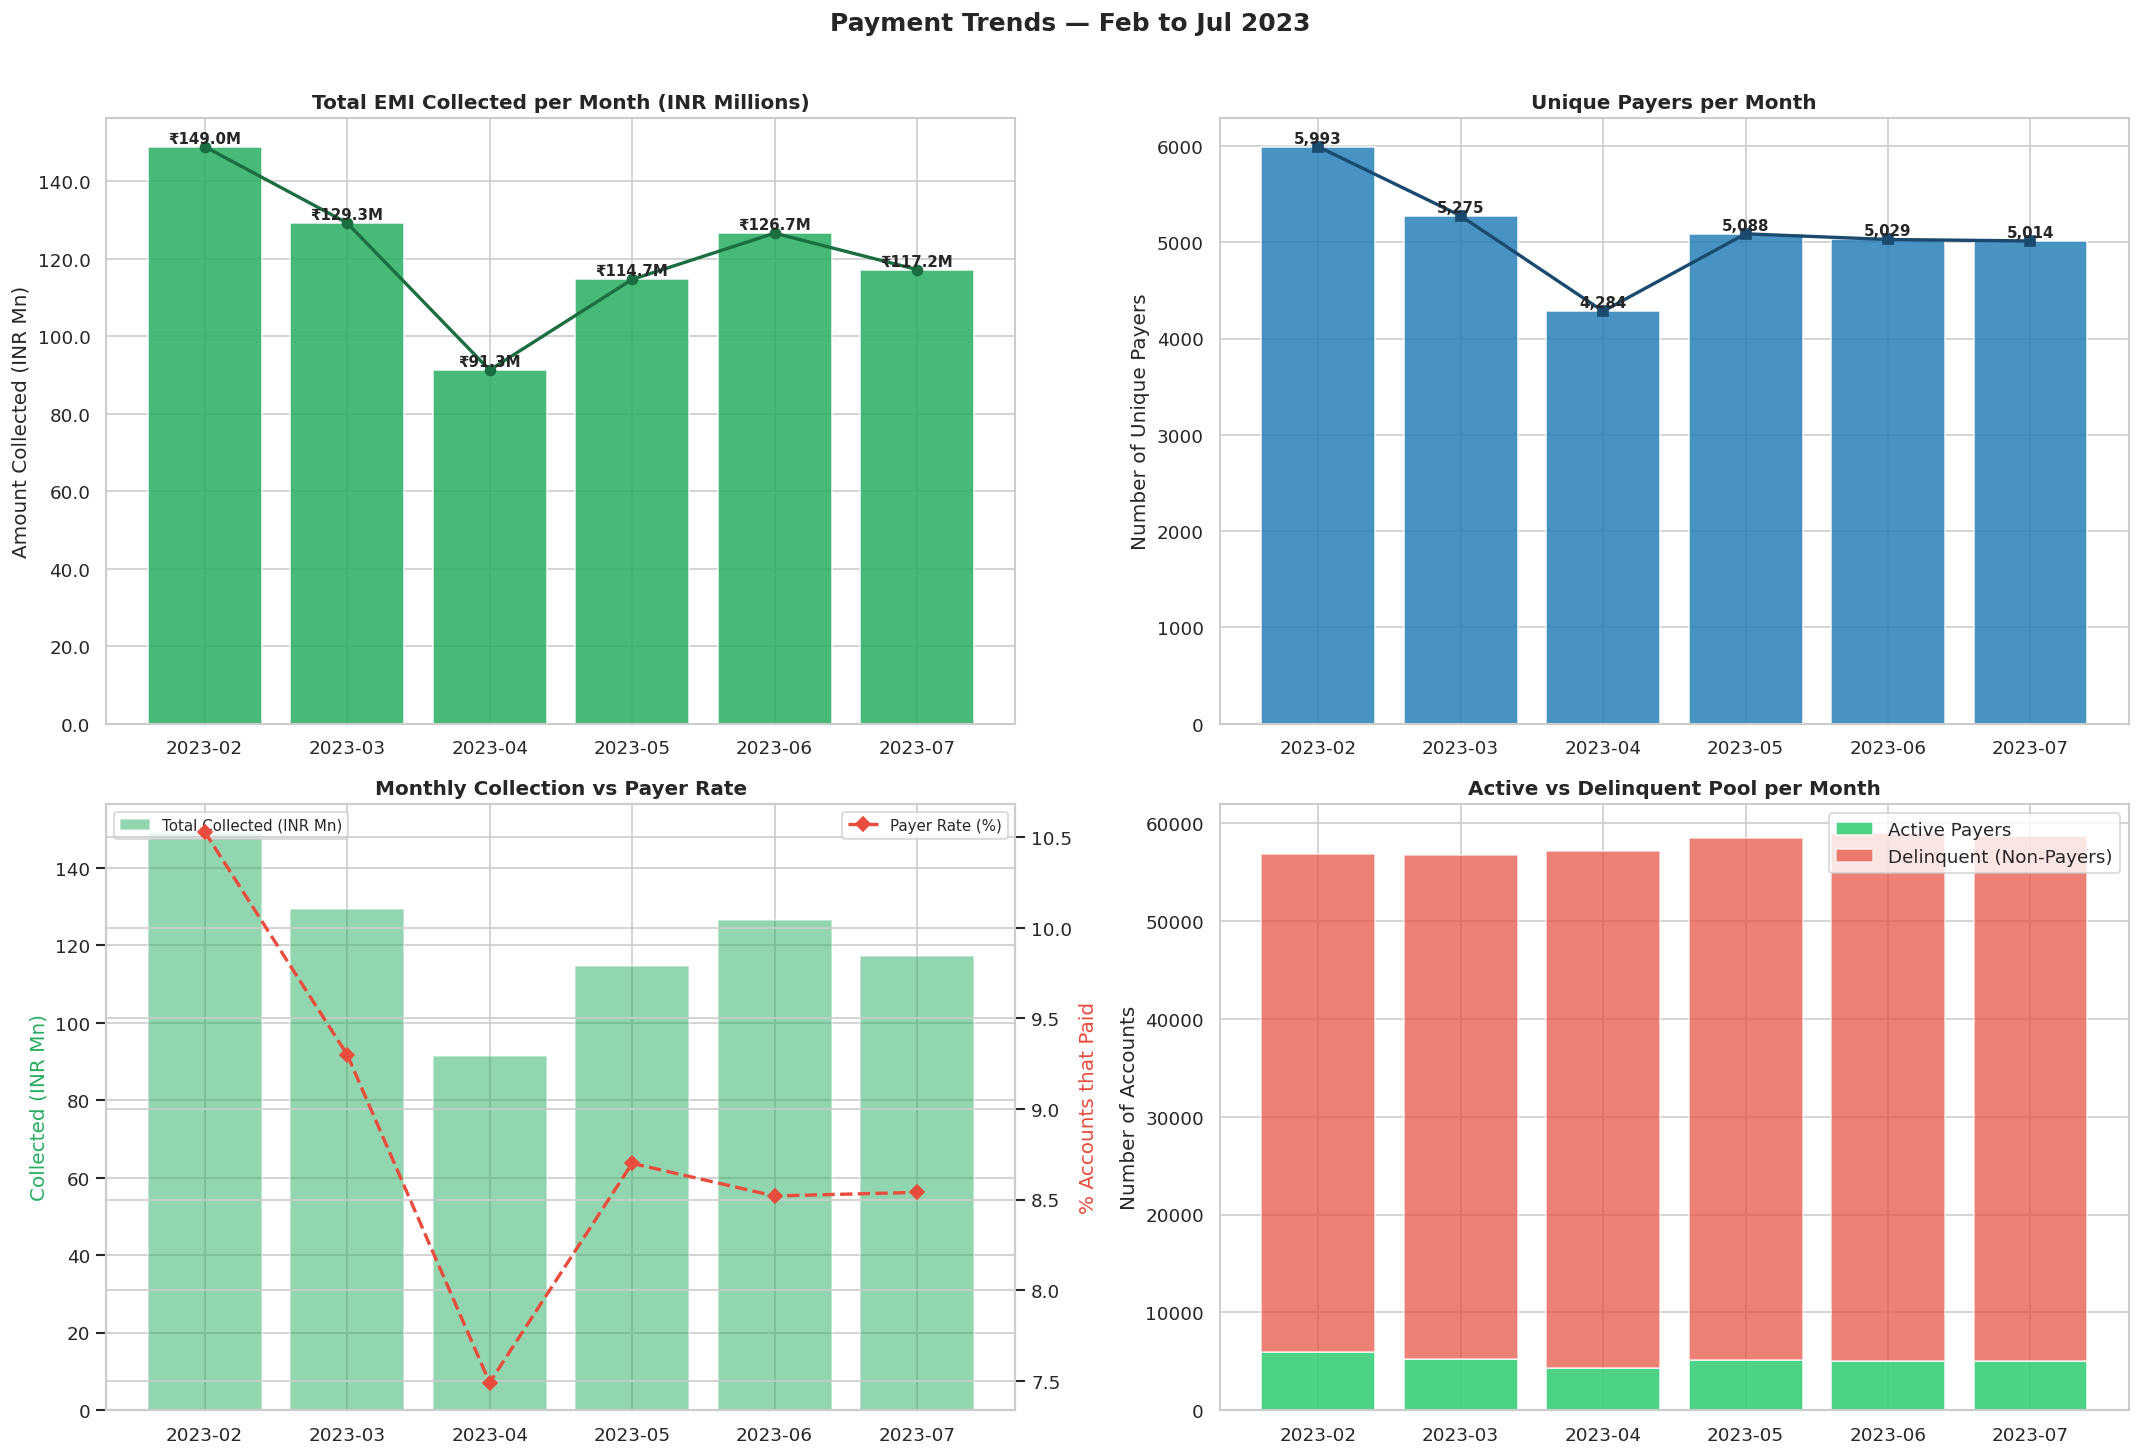

Saved: eda_payment_trends.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Payment Trends — Feb to Jul 2023', fontsize=15, fontweight='bold', y=1.01)

months = monthly['month_end_date']

# Chart 1: Total EMI Collected (INR Millions)
axes[0, 0].bar(months, monthly['total_collected'] / 1e6,
               color='#27ae60', alpha=0.85, edgecolor='white')
axes[0, 0].plot(months, monthly['total_collected'] / 1e6,
                'o-', color='#1a6e3f', linewidth=2)
axes[0, 0].set_title('Total EMI Collected per Month (INR Millions)', fontweight='bold')
axes[0, 0].set_ylabel('Amount Collected (INR Mn)')
axes[0, 0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
for i, val in enumerate(monthly['total_collected']):
    axes[0, 0].text(i, val / 1e6 + 1, f'₹{val/1e6:.1f}M',
                    ha='center', fontsize=9, fontweight='bold')

# Chart 2: Number of Unique Payers per Month
axes[0, 1].bar(months, monthly['unique_payers'],
               color='#2980b9', alpha=0.85, edgecolor='white')
axes[0, 1].plot(months, monthly['unique_payers'],
                's-', color='#1a4a6e', linewidth=2)
axes[0, 1].set_title('Unique Payers per Month', fontweight='bold')
axes[0, 1].set_ylabel('Number of Unique Payers')
for i, val in enumerate(monthly['unique_payers']):
    axes[0, 1].text(i, val + 40, f'{int(val):,}',
                    ha='center', fontsize=9, fontweight='bold')

# Chart 3: Dual-axis — Amount Collected vs Payer Rate
ax_bar  = axes[1, 0]
ax_line = ax_bar.twinx()
ax_bar.bar(months, monthly['total_collected'] / 1e6,
           color='#27ae60', alpha=0.5, label='Total Collected (INR Mn)')
ax_line.plot(months, monthly['payer_rate_pct'],
             'D--', color='#e74c3c', linewidth=2, label='Payer Rate (%)')
ax_bar.set_title('Monthly Collection vs Payer Rate', fontweight='bold')
ax_bar.set_ylabel('Collected (INR Mn)', color='#27ae60')
ax_line.set_ylabel('% Accounts that Paid', color='#e74c3c')
ax_bar.legend(loc='upper left',  fontsize=9)
ax_line.legend(loc='upper right', fontsize=9)

# Chart 4: Active vs Delinquent Pool (Stacked)
axes[1, 1].bar(months, monthly['unique_payers'],
               label='Active Payers', color='#2ecc71', alpha=0.85)
axes[1, 1].bar(months, monthly['delinquent_accounts'],
               bottom=monthly['unique_payers'],
               label='Delinquent (Non-Payers)', color='#e74c3c', alpha=0.7)
axes[1, 1].set_title('Active vs Delinquent Pool per Month', fontweight='bold')
axes[1, 1].set_ylabel('Number of Accounts')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('eda_payment_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eda_payment_trends.png")

### 5.3 Overall Summary

A quick summary of the full 6-month dataset combined — useful as a headline figure for any presentation or report.

In [11]:
total_active     = df_clean['is_payer'].sum()
total_delinquent = (df_clean['is_payer'] == 0).sum()
total_pool       = len(df_clean)

print("=" * 52)
print("  OVERALL POOL SUMMARY  (All 6 Months Combined)")
print("=" * 52)
print(f"  Total Account-Months          : {total_pool:>10,}")
print(f"  Active Payers                 : {total_active:>10,}  ({total_active/total_pool*100:.1f}%)")
print(f"  Delinquent (Non-Payers)       : {total_delinquent:>10,}  ({total_delinquent/total_pool*100:.1f}%)")
print(f"  Total Amount Collected        : Rs {df_clean['Pmt_amount'].sum():>12,.0f}")
print(f"  Avg Payment (payers only)     : Rs {df_clean.loc[df_clean['is_payer']==1, 'Pmt_amount'].mean():>8,.0f}")
print("=" * 52)

  OVERALL POOL SUMMARY  (All 6 Months Combined)
  Total Account-Months          :    346,997
  Active Payers                 :     30,683  (8.8%)
  Delinquent (Non-Payers)       :    316,314  (91.2%)
  Total Amount Collected        : Rs  728,198,458
  Avg Payment (payers only)     : Rs   23,733


---
## 6. Feature Engineering & Model Preparation

Now we get the data ready for the models. A few important decisions here:

**Why stratified split?**
Only ~9% of records are payers. Without `stratify=y`, we might accidentally give the test set 15% payers and the training set only 6% — making our evaluation unfair. Stratifying ensures both sets have the same 9% ratio.

**Why `class_weight='balanced'`?**
If we train without adjustment, the model will just predict "Non-Payer" for everyone and be 91% accurate — which is useless. Balanced weighting forces the model to actually learn from the minority (payer) class.

In [12]:
features = [
    'Principal_outstanding', 'dpd_days',         'dpd_bucket',
    'prod_name',             'disb_amt',          'tenor',
    'roi',                   'emi',               'cibil_score',
    'residence_state',       'final_veri_monthly_income',
    'final_dbr',             'loan_program_type',
    'cibil_missing_flag',    'loan_age_days',
    'gwo_amt',               'dpd_days_wo'
]

X = df_clean[features].copy()
y = df_clean['is_payer']

# Encode categorical columns as ordinal numbers
# handle_unknown='use_encoded_value' means unseen categories at inference
# time get mapped to -1 rather than throwing an error
cat_cols = ['dpd_bucket', 'prod_name', 'residence_state', 'loan_program_type']
enc      = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[cat_cols] = enc.fit_transform(X[cat_cols].astype(str))

# Fill any remaining NaNs in numeric columns
for col in ['Principal_outstanding', 'dpd_days', 'tenor']:
    if X[col].isnull().any():
        X[col] = X[col].fillna(X[col].median())

# Stratified split — preserves the 9% payer ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features — Logistic Regression needs this, Random Forest doesn't
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training set : {X_train.shape[0]:,} rows | Payer rate: {y_train.mean()*100:.1f}%")
print(f"Test set     : {X_test.shape[0]:,} rows  | Payer rate: {y_test.mean()*100:.1f}%")
print(f"\nClass imbalance ratio (non-payer : payer) approx {(1-y_train.mean())/y_train.mean():.0f} : 1")
print("Using class_weight='balanced' in both models to handle this.")

Training set : 277,597 rows | Payer rate: 8.8%
Test set     : 69,400 rows  | Payer rate: 8.8%

Class imbalance ratio (non-payer : payer) approx 10 : 1
Using class_weight='balanced' in both models to handle this.


---
## 7. Model Training & Evaluation

We train two models and compare them:

1. **Logistic Regression** — a simple, interpretable baseline. Good for understanding direction of effects.
2. **Random Forest** — an ensemble of decision trees. Usually more accurate, captures non-linear patterns.

We evaluate both using **ROC-AUC** — a score between 0.5 (random guessing) and 1.0 (perfect). It's the right metric here because our classes are imbalanced, so plain accuracy would be misleading.

In [13]:
# --- Model 1: Logistic Regression ---
lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)
lr.fit(X_train_scaled, y_train)
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]

# --- Model 2: Random Forest ---
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_probs = rf.predict_proba(X_test)[:, 1]

# --- ROC-AUC Scores ---
lr_auc = roc_auc_score(y_test, lr_probs)
rf_auc = roc_auc_score(y_test, rf_probs)

print("=" * 50)
print(f"  Logistic Regression   ROC-AUC : {lr_auc:.4f}")
print(f"  Random Forest         ROC-AUC : {rf_auc:.4f}")
print("=" * 50)
print(f"  Random Forest outperforms LR by {(rf_auc - lr_auc)*100:.2f} AUC points")

  Logistic Regression   ROC-AUC : 0.8000
  Random Forest         ROC-AUC : 0.8324
  Random Forest outperforms LR by 3.24 AUC points


### Model Results — ROC Curves & Feature Importance

- **ROC Curves** show how well each model separates payers from non-payers across all decision thresholds. The further the curve bows towards the top-left, the better.
- **Feature Importance** (from Random Forest) shows which variables the model relied on most. This is useful for business insights — it tells us what actually predicts payment behaviour.

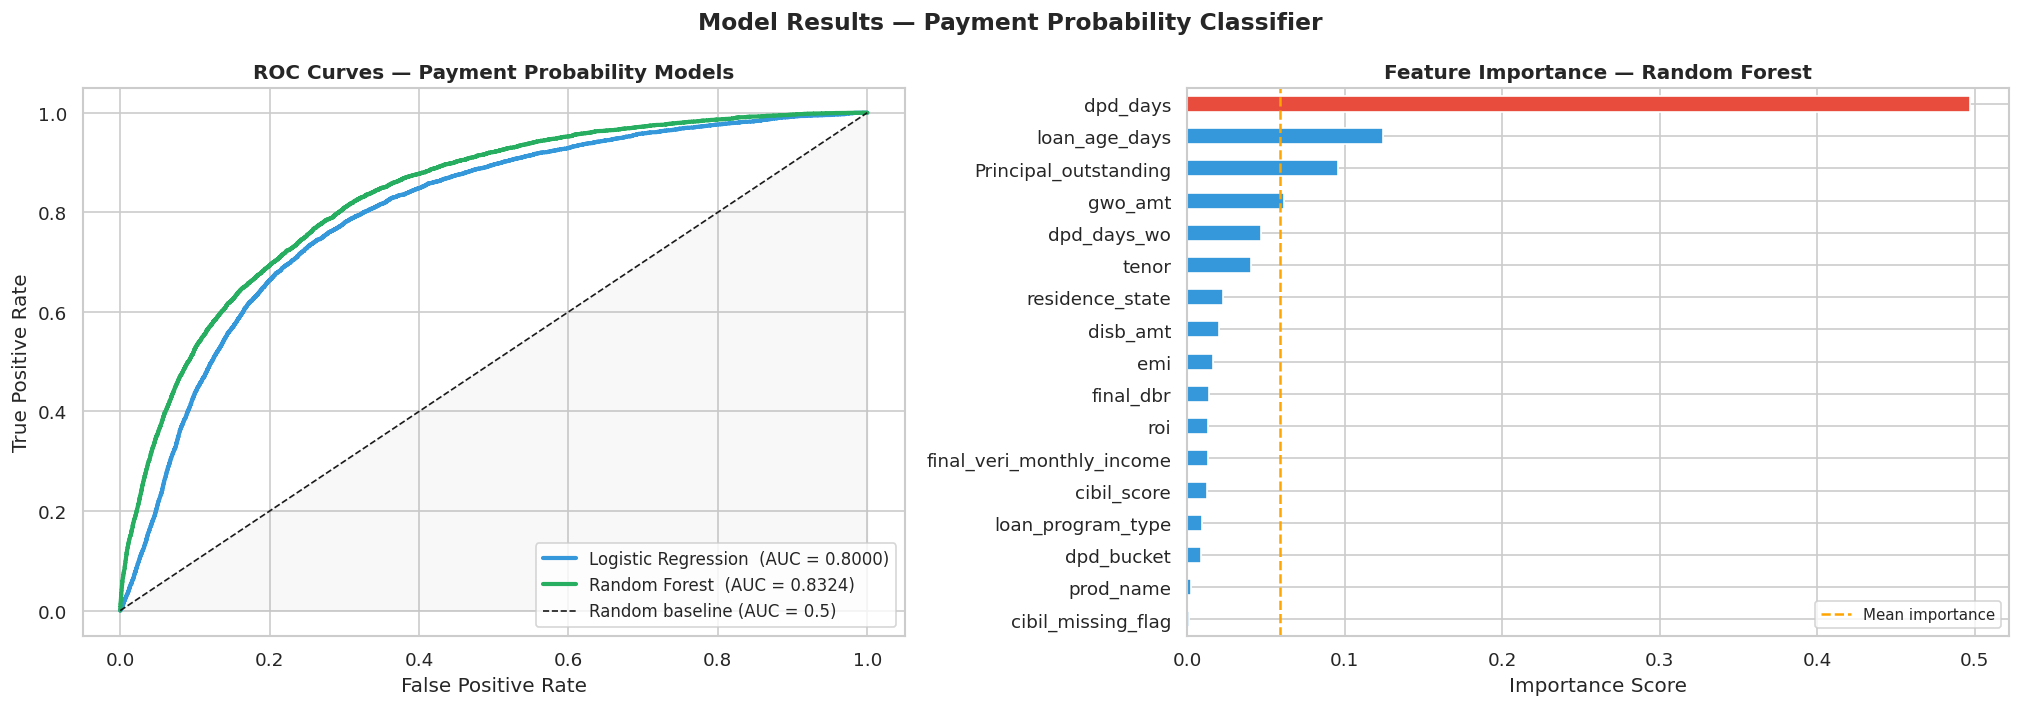

Saved: model_results.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle('Model Results — Payment Probability Classifier', fontsize=14, fontweight='bold')

# Chart 1: ROC Curves for both models
for name, probs, color in [
    ('Logistic Regression', lr_probs, '#3498db'),
    ('Random Forest',       rf_probs, '#27ae60')
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc         = roc_auc_score(y_test, probs)
    axes[0].plot(fpr, tpr, label=f'{name}  (AUC = {auc:.4f})',
                 color=color, linewidth=2.5)

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline (AUC = 0.5)')
axes[0].fill_between([0, 1], [0, 1], alpha=0.05, color='grey')
axes[0].set_title('ROC Curves — Payment Probability Models', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right', fontsize=10)

# Chart 2: Feature Importance (Random Forest)
importances = pd.Series(rf.feature_importances_, index=features).sort_values()
colors_fi   = ['#e74c3c' if v == importances.max() else '#3498db' for v in importances.values]
importances.plot(kind='barh', ax=axes[1], color=colors_fi)
axes[1].set_title('Feature Importance — Random Forest', fontweight='bold')
axes[1].set_xlabel('Importance Score')
axes[1].axvline(x=importances.mean(), color='orange', linestyle='--', label='Mean importance')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('model_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_results.png")

---
## 8. Conclusions & Next Steps

### What We Found

| Finding | Detail |
|---|---|
| Dataset size | 348,151 account-month records across 6 months |
| Class imbalance | Only ~9% of accounts made a payment in any given month |
| Top features | `dpd_days`, `Principal_outstanding`, `loan_age_days`, `gwo_amt` drive most predictions |
| Best model | Random Forest outperforms Logistic Regression on ROC-AUC |
| CIBIL insight | A significant portion of accounts have no credit history (CIBIL = 0), which itself is a useful signal |

### Recommendations & Next Steps

1. **Threshold tuning** — Our models output probabilities. For real-world use, pick a threshold that balances false positives (wasted collection calls) vs false negatives (missed payments). Consider using Precision-Recall curve instead of ROC for this.

2. **Try XGBoost or LightGBM** — These gradient-boosted models typically outperform Random Forest on tabular financial data, especially when class imbalance is severe.

3. **Recovery team feature** — Adding information about which recovery agent/team handled an account could significantly improve predictions.

4. **Temporal validation** — Instead of a random 80/20 split, train on Feb–May and test on Jun–Jul. This more accurately reflects real deployment conditions where we predict the future.

5. **Fill missing state/city data** — Currently ~many accounts show 'Unknown' for geographic fields. Linking pincode to state/city via a lookup table would recover this signal cleanly.

---
